# **Interface enrichment analysis**

In [1]:
import harreman
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import muon as mu
import seaborn as sns
import matplotlib.pyplot as plt
import mplscience
from scipy.stats import spearmanr, kruskal, mannwhitneyu, wilcoxon, zscore
from statsmodels.stats.multitest import multipletests
from sklearn.neighbors import NearestNeighbors
from plotnine import *
import warnings
warnings.filterwarnings("ignore")


BASE_PATH = "/home/projects/nyosef/oier/Harreman_files/Slide_seq_lung"
ADATA_PATH = os.path.join(BASE_PATH, 'h5ads')
DATA_PATH = os.path.join(BASE_PATH, 'data')
PLOTS_PATH = os.path.join(BASE_PATH, 'plots')

/home/projects/nyosef/oier/mambaforge/envs/harreman_pip-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/projects/nyosef/oier/mambaforge/envs/harreman_pip-env/lib/python3.12/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
COLOC_COLS = [
    'E2__ESR1', 'E2__ESR2', 'thromboxane__TBXA2R',
    'GABA__GABRA1', 'GABA__GABRG2', 'testosterone__AR',
    'dopamine__DRD1', 'dopamine__DRD2', 'dopamine__DRD3',
    'dopamine__DRD4', 'dopamine__DRD5',
]
 
METHOD_COLORS = {'Harreman': '#D9D9D9', 'scCellFie': '#B2ABD2'}

## Functions

In [3]:
# ---------------------------------------------------------------------------
# 1.  Gini index
# ---------------------------------------------------------------------------
 
def gini(x):
    """
    Compute the Gini index of a non-negative vector x.
    Returns a value in [0, 1]: 0 = perfectly equal, 1 = maximally unequal.
    Handles NaN by dropping them.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0 or x.sum() == 0:
        return np.nan
    # Shift to non-negative if needed (z-scores can be negative)
    x = x - x.min()
    if x.sum() == 0:
        return 0.0
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * x) / (n * x.sum())) - (n + 1) / n

In [4]:
# ---------------------------------------------------------------------------
# 2.  Primary analysis: discrete cell type labels
# ---------------------------------------------------------------------------
 
def compute_gini_discrete(
    adata,
    score_cols,
    cell_type_col,
    sample_col,
    method_name,
    min_cells_per_type=5,
):
    """
    For each (sample, feature), compute:
      1. Mean score per cell type
      2. Z-score the means across cell types (within sample × feature)
      3. Gini index of the z-scored means
 
    Z-scoring before Gini ensures that the metric reflects relative
    specificity rather than absolute score magnitude, making Harreman
    and scCellFie scores comparable on the same scale.
 
    Parameters
    ----------
    adata : AnnData
        Must have cell_type_col and sample_col in .obs, and score_cols
        in .obs.
    score_cols : list of str
    cell_type_col : str
    sample_col : str
    method_name : str
    min_cells_per_type : int
        Minimum cells per cell type to include it in Gini computation.
 
    Returns
    -------
    pd.DataFrame  columns: sample, feature, gini, method, approach
    """
    available = [c for c in score_cols if c in adata.obs.columns]
    missing = set(score_cols) - set(available)
    if missing:
        warnings.warn(f"[{method_name}] Missing score columns: {missing}")
 
    rows = []
    for sample, s_idx in adata.obs.groupby(sample_col).groups.items():
        s_obs = adata.obs.loc[s_idx]
 
        for feat in available:
            # mean score per cell type (only types with enough cells)
            ct_means = (
                s_obs.groupby(cell_type_col)[feat]
                .agg(lambda x: x.mean() if len(x) >= min_cells_per_type
                     else np.nan)
                .dropna()
            )
            if len(ct_means) < 2:
                continue
 
            # z-score across cell types
            std = ct_means.std(ddof=1)
            if std < 1e-8:
                # constant across cell types → Gini = 0
                g = 0.0
            else:
                z = (ct_means - ct_means.mean()) / std
                g = gini(z)
 
            rows.append({
                'sample':   sample,
                'feature':  feat,
                'gini':     g,
                'method':   method_name,
                'approach': 'discrete',
            })
 
    return pd.DataFrame(rows)

In [5]:
# ---------------------------------------------------------------------------
# 3.  Sensitivity check: deconvolution-weighted scores
# ---------------------------------------------------------------------------
 
def compute_gini_deconv(
    adata,
    score_cols,
    deconv_cols,
    sample_col,
    method_name,
    min_spots=10,
):
    """
    For each (sample, feature, cell_type), compute the deconvolution-weighted
    mean score:
        weighted_score(ct) = sum(score * proportion_ct) / sum(proportion_ct)
 
    Then z-score across cell types and compute Gini, as in the discrete case.
 
    Parameters
    ----------
    adata : AnnData
    score_cols : list of str   score columns in adata.obs
    deconv_cols : list of str  deconvolution proportion columns in adata.obs
    sample_col : str
    method_name : str
    min_spots : int            minimum spots with proportion > 0 per cell type
 
    Returns
    -------
    pd.DataFrame  columns: sample, feature, gini, method, approach
    """
    available_scores = [c for c in score_cols if c in adata.obs.columns]
    available_deconv = [c for c in deconv_cols if c in adata.obs.columns]
 
    if not available_deconv:
        warnings.warn(f"[{method_name}] No deconvolution columns found.")
        return pd.DataFrame()
 
    rows = []
    for sample, s_idx in adata.obs.groupby(sample_col).groups.items():
        s_obs = adata.obs.loc[s_idx]
 
        for feat in available_scores:
            scores = s_obs[feat].values.astype(float)
            weighted_means = {}
 
            for ct_col in available_deconv:
                proportions = s_obs[ct_col].values.astype(float)
                # only spots with meaningful proportion
                mask = (proportions > 0.05) & ~np.isnan(scores)
                if mask.sum() < min_spots:
                    continue
                weighted_means[ct_col] = (
                    np.sum(scores[mask] * proportions[mask])
                    / np.sum(proportions[mask])
                )
 
            if len(weighted_means) < 2:
                continue
 
            wm = pd.Series(weighted_means)
            std = wm.std(ddof=1)
            if std < 1e-8:
                g = 0.0
            else:
                z = (wm - wm.mean()) / std
                g = gini(z)
 
            rows.append({
                'sample':   sample,
                'feature':  feat,
                'gini':     g,
                'method':   method_name,
                'approach': 'deconvolution',
            })
 
    return pd.DataFrame(rows)

In [6]:
# ---------------------------------------------------------------------------
# 4.  Main benchmark function
# ---------------------------------------------------------------------------
 
def run_gini_benchmark(
    harreman_adata,
    coloc_adata,
    coloc_cols=None,
    cell_type_col='cell_type',
    sample_col='sample',
    deconv_cols=None,
    min_cells_per_type=5,
    min_spots=10,
):
    """
    Compute Gini index for Harreman exchange scores and scCellFie
    colocalization scores, using both discrete labels (primary) and
    deconvolution scores (sensitivity check).
 
    Parameters
    ----------
    harreman_adata : AnnData
        Must have Harreman exchange scores in .obs (from interacting cell
        results) and cell_type_col, sample_col in .obs.
    coloc_adata : AnnData
        Must have colocalization scores in .obs columns.
    coloc_cols : list of str, optional
    cell_type_col : str
    sample_col : str
    deconv_cols : list of str, optional
        Deconvolution proportion columns in both adatas. If None,
        sensitivity check is skipped.
    min_cells_per_type : int
    min_spots : int
 
    Returns
    -------
    results_df : pd.DataFrame  all Gini results (both approaches)
    mwu_df     : pd.DataFrame  per-sample MWU (discrete approach)
    """
    if coloc_cols is None:
        coloc_cols = COLOC_COLS
 
    # Extract Harreman scores into obs
    # Scores are already in obs (pre-populated before subsetting)
    print("Reading Harreman scores from obs...")
    harreman_score_cols = harreman_adata.uns['metabolites'].tolist()
    harreman_adata_copy = harreman_adata.copy()
 
    # Verify cell type column
    for adata, name in [(harreman_adata_copy, 'harreman_adata'),
                        (coloc_adata, 'coloc_adata')]:
        if cell_type_col not in adata.obs.columns:
            raise ValueError(
                f"'{cell_type_col}' not found in {name}.obs. "
                f"Available: {adata.obs.columns.tolist()}"
            )
 
    # ---- Discrete label analysis ----------------------------------------
    print("Computing Gini (discrete labels)...")
    h_disc = compute_gini_discrete(
        harreman_adata_copy, harreman_score_cols,
        cell_type_col, sample_col, 'Harreman', min_cells_per_type,
    )
    c_disc = compute_gini_discrete(
        coloc_adata, coloc_cols,
        cell_type_col, sample_col, 'scCellFie', min_cells_per_type,
    )
    print(f"  Harreman: {len(h_disc)} (sample, feature) pairs")
    print(f"  scCellFie: {len(c_disc)} (sample, feature) pairs")
 
    # ---- Deconvolution sensitivity check --------------------------------
    deconv_results = []
    if deconv_cols is not None:
        print("Computing Gini (deconvolution weights)...")
        h_deconv = compute_gini_deconv(
            harreman_adata_copy, harreman_score_cols, deconv_cols,
            sample_col, 'Harreman', min_spots,
        )
        c_deconv = compute_gini_deconv(
            coloc_adata, coloc_cols, deconv_cols,
            sample_col, 'scCellFie', min_spots,
        )
        deconv_results = [h_deconv, c_deconv]
        print(f"  Harreman (deconv): {len(h_deconv)} pairs")
        print(f"  scCellFie (deconv): {len(c_deconv)} pairs")
    else:
        print("Skipping deconvolution sensitivity check (deconv_cols=None).")
 
    results_df = pd.concat(
        [h_disc, c_disc] + deconv_results, ignore_index=True
    )
 
    # ---- Per-sample Mann-Whitney U (discrete only) ----------------------
    disc_df = results_df[results_df['approach'] == 'discrete']
    mwu_rows = []
    for sample in disc_df['sample'].unique():
        h = disc_df[(disc_df['sample'] == sample) &
                    (disc_df['method'] == 'Harreman')]['gini'].dropna()
        s = disc_df[(disc_df['sample'] == sample) &
                    (disc_df['method'] == 'scCellFie')]['gini'].dropna()
        if len(h) < 3 or len(s) < 3:
            continue
        stat, p = mannwhitneyu(h, s, alternative='two-sided')
        mwu_rows.append({
            'sample':           sample,
            'U':                stat,
            'pvalue':           p,
            'harreman_median':  h.median(),
            'sccellfie_median': s.median(),
            'n_harreman':       len(h),
            'n_sccellfie':      len(s),
        })
 
    mwu_df = pd.DataFrame(mwu_rows)
    if not mwu_df.empty:
        mwu_df['padj'] = multipletests(mwu_df['pvalue'], method='fdr_bh')[1]
        mwu_df['sig'] = mwu_df['padj'].apply(
            lambda p: '***' if p < 0.001 else (
                '**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))
 
    print("\n--- Mann-Whitney U summary (Harreman vs scCellFie Gini) ---")
    if not mwu_df.empty:
        print(mwu_df.to_string(index=False, float_format='{:.4f}'.format))
    else:
        print("No per-sample comparisons possible.")
 
    return results_df, mwu_df

In [28]:
# ---------------------------------------------------------------------------
# 5.  Visualisation
# ---------------------------------------------------------------------------
 
def plot_gini(
    results_df,
    mwu_df=None,
    approach='discrete',
    sample_order=None,
    save_path=None,
):
    """
    Per-sample violin + jitter of Gini distributions.
 
    Parameters
    ----------
    results_df : pd.DataFrame  output of run_gini_benchmark()
    mwu_df : pd.DataFrame      output of run_gini_benchmark()
    approach : str             'discrete' or 'deconvolution'
    sample_order : list of str
    save_path : str, optional
    """
    plot_df = results_df[
        (results_df['approach'] == approach) &
        results_df['gini'].notna()
    ].copy()
 
    if plot_df.empty:
        print(f"No data for approach='{approach}'.")
        return
 
    if sample_order is not None:
        sample_ord = [s for s in sample_order if s in plot_df['sample'].unique()]
        plot_df['sample'] = pd.Categorical(
            plot_df['sample'], categories=sample_ord, ordered=True)
    
    # Significance label layer
    sig_df = None
    if mwu_df is not None and not mwu_df.empty:
        sig_df = mwu_df[mwu_df['sig'] != 'ns'].copy()
        if sample_order is not None:
            sig_df['sample'] = pd.Categorical(
                sig_df['sample'], categories=sample_ord, ordered=True)
 
    fig = (
        ggplot(plot_df, aes(x='method', y='gini', fill='method'))
        + geom_boxplot(position=position_dodge(width=0.8), outlier_shape="", color='black', width=0.5)
        + geom_jitter(width=0.15, height=0, size=1, alpha=0.5)
        # + geom_violin(alpha=0.6, color='black', size=0.4)
        # + geom_jitter(aes(color='method'), width=0.15, size=0.8, alpha=0.5)
        + geom_hline(yintercept=0, linetype='dashed', color='grey', size=0.5)
        + geom_segment(
            data=sig_df,
            mapping=aes(x='x_left', xend='x_right', y='y', yend='y'),
            inherit_aes=False,
            color='black',
            size=0.5,
        )
        + geom_text(
            data=sig_df,
            mapping=aes(x=1.5, y='star_y', label='sig'),
            inherit_aes=False,
            size=12,
            ha='center',
        )
        + facet_wrap('~sample', nrow=1)
        + scale_fill_manual(values=METHOD_COLORS)
        + scale_color_manual(values={'Harreman': '#525252', 'scCellFie': '#5E4FA2'})
        + scale_y_continuous(limits=(0, 1))
        + theme_classic()
        + theme(
            legend_position='none',
            strip_text = element_text(size = 14),
            axis_title_x=element_blank(),
            axis_title_y=element_text(size=16),
            axis_text_x=element_text(size=14, rotation=30, hjust=1),
            axis_text_y=element_text(size=14),
            panel_border=element_rect(color='black'),
            figure_size=(6, 4),
        )
        + labs(
            y='Gini index',
        )
    )
    fig.show()
    if save_path:
        fig.save(save_path)
        print(f"Saved to {save_path}")
    return fig
 
 
def plot_gini_global(results_df, sig_df=None, save_path=None):
    plot_df = results_df[results_df['gini'].notna()].copy()

    print("\n--- Global summary ---")
    for approach in plot_df['approach'].unique():
        h = plot_df[(plot_df['method'] == 'Harreman') &
                    (plot_df['approach'] == approach)]['gini']
        s = plot_df[(plot_df['method'] == 'scCellFie') &
                    (plot_df['approach'] == approach)]['gini']
        if len(h) >= 3 and len(s) >= 3:
            from scipy.stats import mannwhitneyu
            stat, p = mannwhitneyu(h, s, alternative='two-sided')
            print(f"  [{approach}] Harreman={h.median():.4f}, "
                  f"scCellFie={s.median():.4f}, p={p:.4e}")

    fig = (
        ggplot(plot_df, aes(x='method', y='gini', fill='method'))
        + geom_boxplot(position=position_dodge(width=0.8),
                       outlier_shape="", color='black', width=0.5)
        + geom_jitter(width=0.15, height=0, size=1, alpha=0.5)
        + geom_hline(yintercept=0, linetype='dashed', color='grey', size=0.6)
        + facet_wrap('~approach')
        + scale_fill_manual(values=METHOD_COLORS)
        + scale_y_continuous(limits=(0, 1))
        + theme_classic()
        + theme(
            legend_position='none',
            strip_text=element_text(size=14),
            axis_title_x=element_blank(),
            axis_title_y=element_text(size=16),
            axis_text_x=element_text(size=14, rotation=30, hjust=1),
            axis_text_y=element_text(size=14),
            panel_border=element_rect(color='black'),
            figure_size=(4.5, 4),
        )
        + labs(y='Gini index')
    )

    if sig_df is not None and not sig_df.empty:
        fig = (fig
            + geom_segment(
                data=sig_df,
                mapping=aes(x='x_left', xend='x_right', y='y', yend='y'),
                inherit_aes=False,
                color='black',
                size=0.5,
            )
            + geom_text(
                data=sig_df,
                mapping=aes(x=1.5, y='star_y', label='sig'),
                inherit_aes=False,
                size=12,
                ha='center',
            )
        )

    fig.show()
    if save_path:
        fig.save(save_path)
        print(f"Saved to {save_path}")
    return fig
 
 
def plot_gini_comparison(results_df, save_path=None):
    """
    Scatter plot comparing discrete vs deconvolution Gini per method,
    to assess sensitivity of the primary result to the annotation approach.
    Only plotted if both approaches are available.
    """
    disc  = results_df[results_df['approach'] == 'discrete'][
        ['sample', 'feature', 'method', 'gini']
    ].rename(columns={'gini': 'gini_discrete'})
    deconv = results_df[results_df['approach'] == 'deconvolution'][
        ['sample', 'feature', 'method', 'gini']
    ].rename(columns={'gini': 'gini_deconv'})
 
    if deconv.empty:
        print("Deconvolution results not available — skipping comparison plot.")
        return
 
    merged = disc.merge(deconv, on=['sample', 'feature', 'method'], how='inner')
    if merged.empty:
        print("No overlapping (sample, feature, method) pairs between approaches.")
        return
    
    from scipy.stats import spearmanr
    for method in merged['method'].unique():
        sub = merged[merged['method'] == method].dropna(
            subset=['gini_discrete', 'gini_deconv'])
        if len(sub) < 3:
            print(f"  [{method}] insufficient non-NaN pairs")
            continue
        rho, p = spearmanr(sub['gini_discrete'], sub['gini_deconv'])
        print(f"  [{method}] Spearman rho(discrete, deconv) = {rho:.3f}, "
            f"p={p:.3e}, n={len(sub)}")
 
    fig = (
        ggplot(merged, aes(x='gini_discrete', y='gini_deconv', color='method'))
        + geom_point(alpha=0.4, size=0.8)
        + geom_abline(slope=1, intercept=0, linetype='dashed', color='grey')
        + scale_color_manual(values={'Harreman': '#525252', 'scCellFie': '#5E4FA2'})
        + facet_wrap('~method')
        + theme_classic()
        + theme(
            legend_position='none',
            strip_text=element_text(size=16),
            axis_title_x=element_text(size=14),
            axis_title_y=element_text(size=14),
            axis_text_x=element_text(size=12),
            axis_text_y=element_text(size=12),
            figure_size=(7, 4),
        )
        + labs(x='Gini (discrete labels)', y='Gini (deconvolution)',
               title='Sensitivity: discrete vs deconvolution Gini')
    )
    fig.show()
    if save_path:
        fig.save(save_path)
    return fig

## Analysis

In [8]:
# ── 1. Load objects ────────────────────────────────────────────────────────
st_adata = sc.read_h5ad(os.path.join(ADATA_PATH, 
                         'Slide_seq_lung_DestVI_v2_revision_adata.h5ad'))
harreman_adata = sc.read_h5ad(f'{ADATA_PATH}/Slide_seq_lung_Harreman_adata.h5ad')
ccc_sccellfie_adata = sc.read_h5ad(f'{ADATA_PATH}/Slide_seq_lung_CCC_scCellFie.h5ad')

In [9]:
# ── 2. Assign discrete cell types from DestVI proportions ─────────────────
cell_types = [ct for ct in st_adata.obsm['proportions'].columns 
              if 'additional' not in ct]
df_z = st_adata.obsm['proportions'][cell_types].apply(zscore, axis=0)
assigned_cell_types = df_z.idxmax(axis=1)

In [10]:
# ── 4. Align ccc_sccellfie_adata to the same spots ────────────────────────
# scCellFie covers only 3 samples — take the intersection with DestVI spots
common_idx = ccc_sccellfie_adata.obs_names.intersection(assigned_cell_types.index)
print(f"scCellFie spots before alignment: {ccc_sccellfie_adata.n_obs}")
print(f"Common spots with DestVI:         {len(common_idx)}")

scCellFie spots before alignment: 49207
Common spots with DestVI:         49207


In [11]:
ccc_sccellfie_adata = ccc_sccellfie_adata[common_idx].copy()
ccc_sccellfie_adata.obs['cell_type'] = assigned_cell_types.loc[common_idx]
for ct in cell_types:
    ccc_sccellfie_adata.obs[ct] = st_adata.obsm['proportions'].loc[
        common_idx, ct]

In [12]:
print(f"\nharreman_adata:       {harreman_adata.n_obs} spots, "
      f"{harreman_adata.obs['sample'].nunique()} samples")
print(f"ccc_sccellfie_adata:  {ccc_sccellfie_adata.n_obs} spots, "
      f"{ccc_sccellfie_adata.obs['sample'].nunique()} samples")
print(f"\nCell types: {sorted(cell_types)}")
print(f"\nSamples in harreman:  "
      f"{sorted(harreman_adata.obs['sample'].unique())}")
print(f"Samples in scCellFie: "
      f"{sorted(ccc_sccellfie_adata.obs['sample'].unique())}")


harreman_adata:       200394 spots, 7 samples
ccc_sccellfie_adata:  49207 spots, 3 samples

Cell types: ['B cell', 'CD8+ T cell', 'DC', 'Endothelial', 'Fibroblast', 'Mast cell', 'Misc/Undetermined', 'Monocyte', 'NK', 'NKT', 'Plasma cell', 'T-Helper', 'T-Reg', 'TAM', 'Tumor']

Samples in harreman:  ['Puck_200727_08', 'Puck_200727_09', 'Puck_200727_10', 'Puck_220408_13', 'Puck_220408_14', 'Puck_220408_15', 'Puck_220408_20']
Samples in scCellFie: ['Puck_200727_08', 'Puck_200727_09', 'Puck_200727_10']


In [13]:
# Add this BEFORE the subsetting step
harreman_scores_full = pd.DataFrame(
    harreman_adata.uns['interacting_cell_results']['np']['m']['cs'],
    index=harreman_adata.obs_names,
    columns=harreman_adata.uns['metabolites'],
)

# Then subset as before
shared_samples = ccc_sccellfie_adata.obs['sample'].unique()
harreman_adata_gini = harreman_adata[
    harreman_adata.obs['sample'].isin(shared_samples)
].copy()
harreman_adata_gini.obs['cell_type'] = assigned_cell_types.loc[
    harreman_adata_gini.obs_names]
for ct in cell_types:
    harreman_adata_gini.obs[ct] = st_adata.obsm['proportions'].loc[
        harreman_adata_gini.obs_names, ct]

# Store the restricted scores directly in obs
for col in harreman_scores_full.columns:
    harreman_adata_gini.obs[col] = harreman_scores_full.loc[
        harreman_adata_gini.obs_names, col].values

In [14]:
SAMPLE_ORDER_LUNG = ['Puck_200727_08', 'Puck_200727_09', 'Puck_200727_10']

results_df, mwu_df = run_gini_benchmark(
    harreman_adata=harreman_adata_gini,
    coloc_adata=ccc_sccellfie_adata,
    coloc_cols=COLOC_COLS,
    cell_type_col='cell_type',
    sample_col='sample',
    deconv_cols=cell_types,
)

Reading Harreman scores from obs...
Computing Gini (discrete labels)...
  Harreman: 708 (sample, feature) pairs
  scCellFie: 24 (sample, feature) pairs
Computing Gini (deconvolution weights)...
  Harreman (deconv): 708 pairs
  scCellFie (deconv): 24 pairs

--- Mann-Whitney U summary (Harreman vs scCellFie Gini) ---
        sample         U  pvalue  harreman_median  sccellfie_median  n_harreman  n_sccellfie   padj sig
Puck_200727_08 1315.0000  0.0392           0.5839            0.3803         230            8 0.0589  ns
Puck_200727_09 1463.5000  0.0001           0.5873            0.2136         224            7 0.0003 ***
Puck_200727_10 1090.5000  0.1531           0.5559            0.4018         210            8 0.1531  ns


In [15]:
def add_star_y(mwu_df, results_df, value_col='gini', offset_frac=0.05):
    """
    Add star placement and bracket segment columns to mwu_df.

    Columns added:
        y        : y position of horizontal bracket segment
        star_y   : y position of significance label (slightly above bracket)
        x_left   : left x of bracket (Harreman, position 1)
        x_right  : right x of bracket (scCellFie, position 2)
    """
    mwu_df = mwu_df.copy()

    rows = {}
    for sample in mwu_df['sample']:
        vals = results_df[
            results_df['sample'] == sample
        ][value_col].dropna()

        if len(vals) == 0:
            rows[sample] = {'bracket': 1.0, 'range': 0.1}
            continue

        p95    = vals.quantile(0.95)
        vrange = vals.max() - vals.min()
        offset = vrange * offset_frac
        rows[sample] = {
            'bracket': p95 + offset,
            'range':   vrange,
        }

    mwu_df['y'] = results_df[value_col].max() + 0.03
    mwu_df["star_y"] = mwu_df["y"] + 0.01
    mwu_df['x_left']  = 1.0
    mwu_df['x_right'] = 2.0

    return mwu_df

In [16]:
mwu_df = add_star_y(mwu_df, results_df, value_col='gini', offset_frac=0.05)

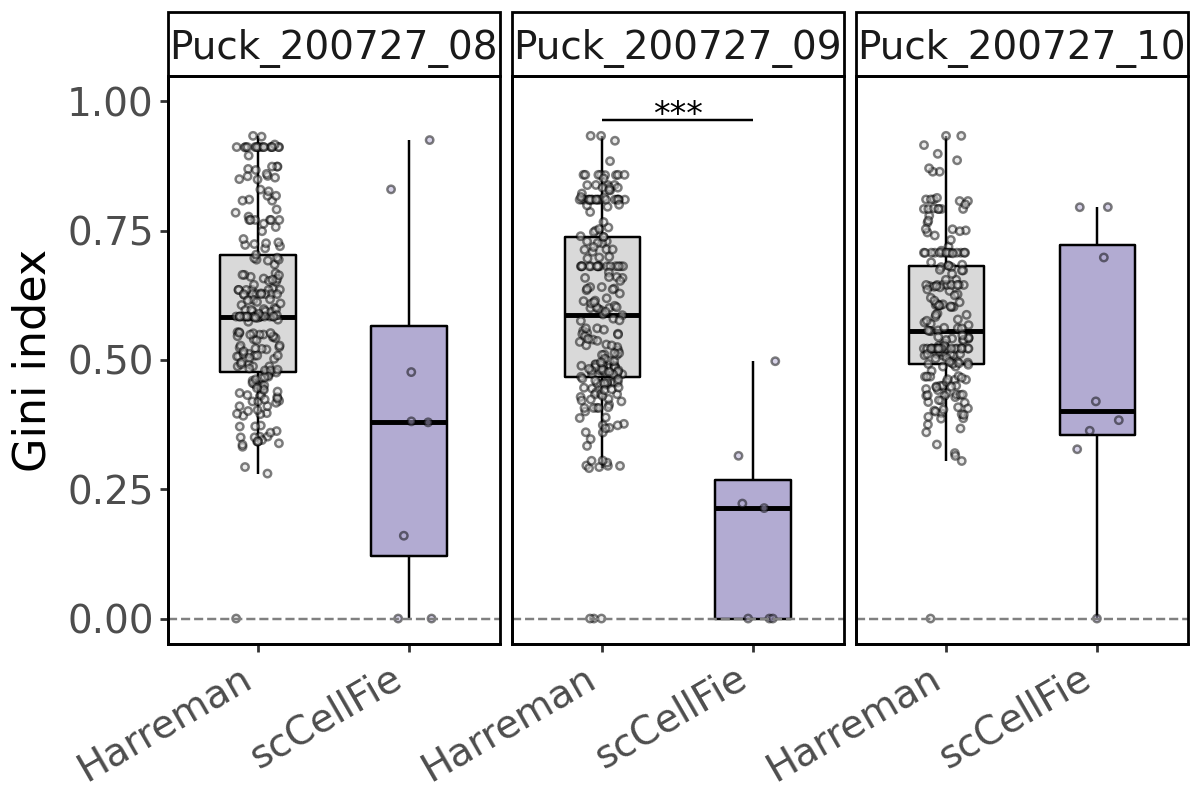

Saved to /home/projects/nyosef/oier/Harreman_files/Slide_seq_lung/plots/gini_discrete_per_sample.svg


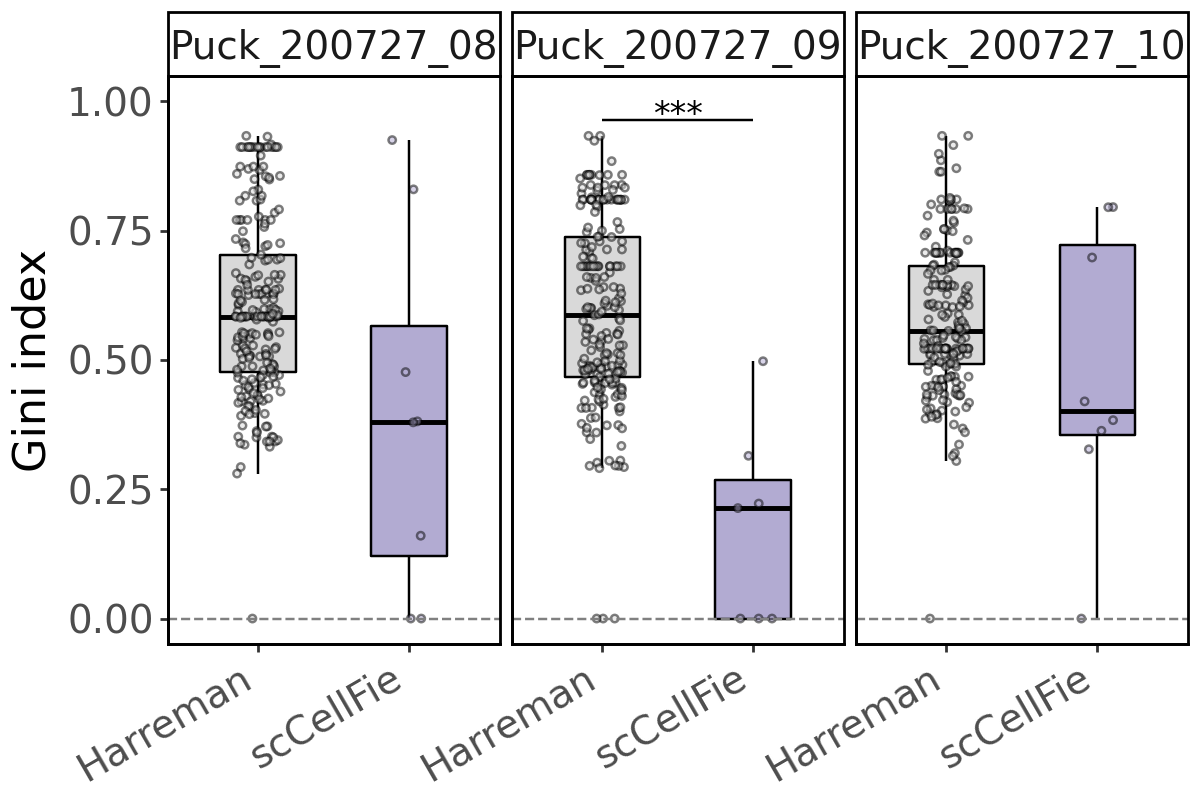

In [29]:
# Per-sample violin
plot_gini(
    results_df, mwu_df,
    approach='discrete',
    sample_order=SAMPLE_ORDER_LUNG,
    save_path=f'{PLOTS_PATH}/gini_discrete_per_sample.svg',
)

In [18]:
# Run this after run_gini_benchmark()
from scipy.stats import mannwhitneyu

plot_df_global = results_df[results_df['gini'].notna()].copy()

global_stats_rows = []
for approach in plot_df_global['approach'].unique():
    h = plot_df_global[(plot_df_global['method'] == 'Harreman') &
                       (plot_df_global['approach'] == approach)]['gini']
    s = plot_df_global[(plot_df_global['method'] == 'scCellFie') &
                       (plot_df_global['approach'] == approach)]['gini']
    if len(h) >= 3 and len(s) >= 3:
        _, p = mannwhitneyu(h, s, alternative='two-sided')
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else
              ('*' if p < 0.05 else 'ns'))
        vals   = plot_df_global[plot_df_global['approach'] == approach]['gini']
        p95    = vals.quantile(0.95)
        vrange = vals.max() - vals.min()
        global_stats_rows.append({
            'approach': approach,
            'sig':      sig,
            'y':        vals.max() + 0.03,
            'star_y':   vals.max() + 0.03 + 0.01,
            'x_left':   1.0,
            'x_right':  2.0,
        })

sig_global_gini_df = pd.DataFrame(global_stats_rows)
sig_global_gini_df = sig_global_gini_df[sig_global_gini_df['sig'] != 'ns']


--- Global summary ---
  [discrete] Harreman=0.5839, scCellFie=0.3631, p=1.4412e-05
  [deconvolution] Harreman=0.3362, scCellFie=0.2511, p=1.0209e-04


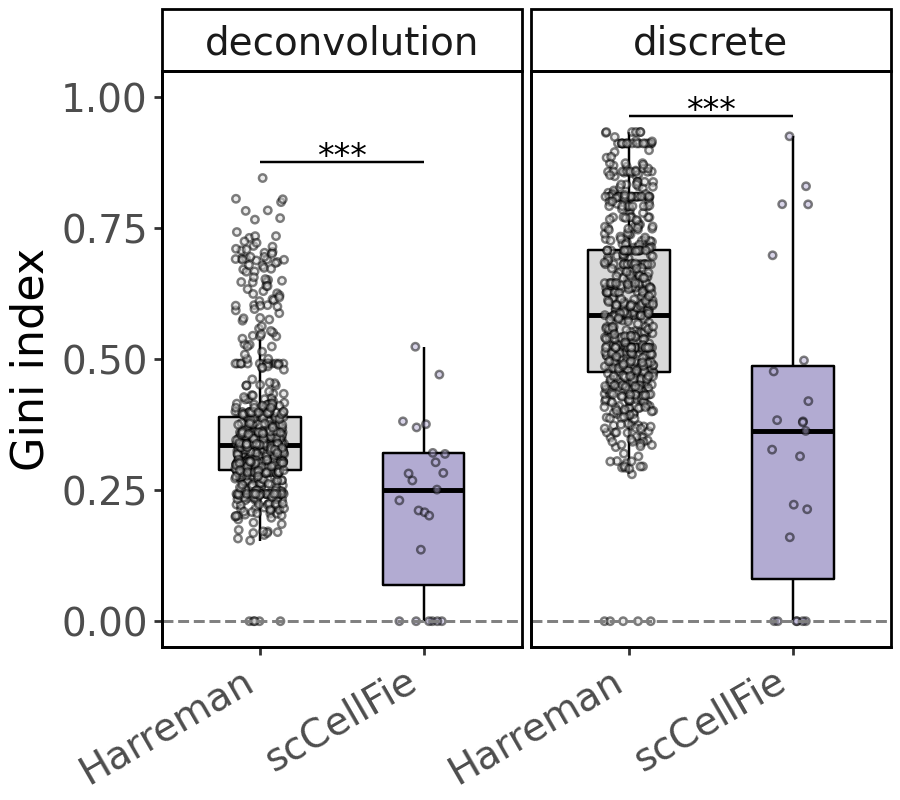

Saved to /home/projects/nyosef/oier/Harreman_files/Slide_seq_lung/plots/gini_global.svg


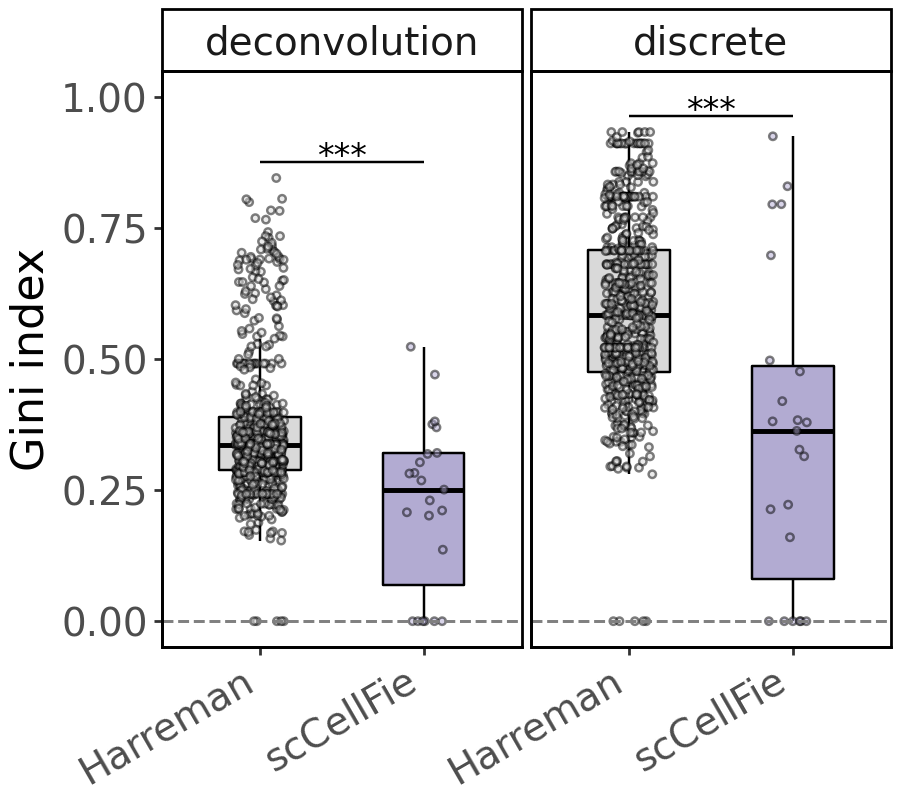

In [30]:
# Global summary (both approaches)
plot_gini_global(
    results_df, sig_global_gini_df,
    save_path=f'{PLOTS_PATH}/gini_global.svg',
)

  [Harreman] Spearman rho(discrete, deconv) = 0.192, p=1.048e-06, n=640
  [scCellFie] Spearman rho(discrete, deconv) = 0.788, p=1.333e-05, n=22


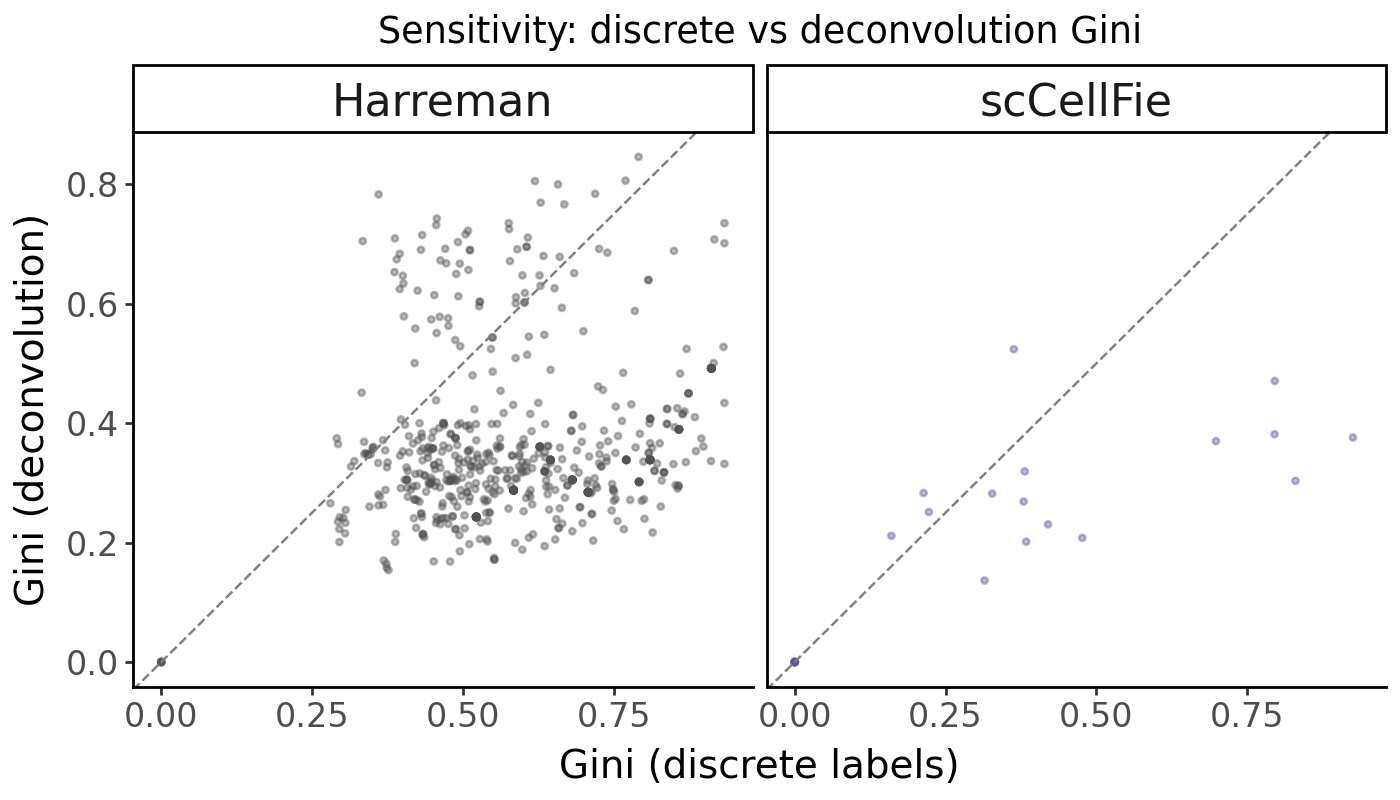

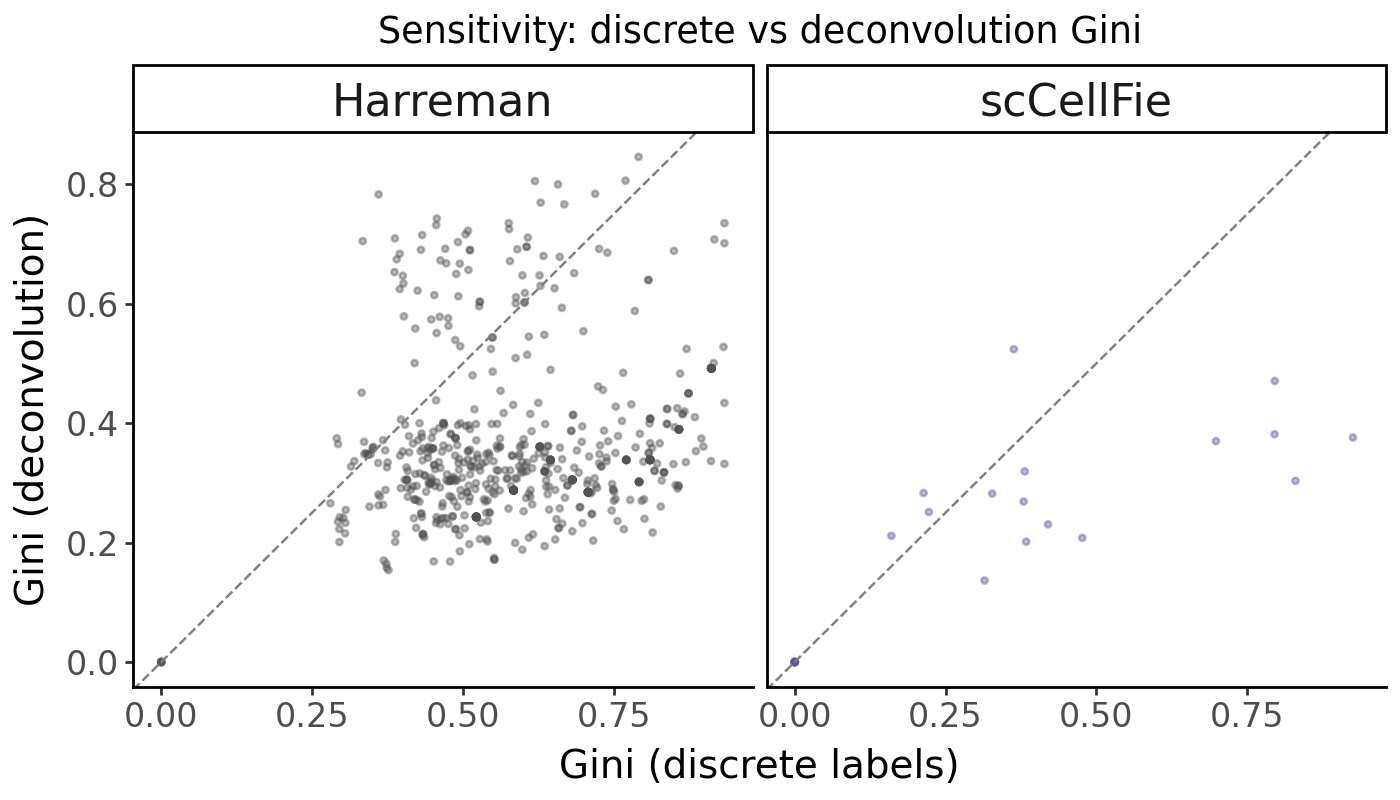

In [20]:
# Sensitivity check: discrete vs deconvolution
plot_gini_comparison(
    results_df,
    save_path=f'{PLOTS_PATH}/gini_sensitivity.svg',
)